<a href="https://colab.research.google.com/github/petermatta/2026_Intro_Python/blob/main/1_4_matplotlib_and_xarray_practice_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Notebook-friendly copy of `part-I/1.4-matplotlib-and-xarray-practice-exercises.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

# Practice Exercises

**ℹ️ How to use these exercises**

Attempt each from scratch in the empty code cell. Run the shared setup cell below first — exercises 1 to 9 use the synthetic station records it builds, and exercises 7, 10, and 12 also draw on its random-number generator. Label every axis with its unit.

In [3]:
# Pre-supplied: run this first. Three synthetic station records and a humidity series,
# standing in for a year of daily weather observations.
import numpy as np
import matplotlib.pyplot as plt

In [4]:
rng = np.random.default_rng(1)

In [5]:
days = np.arange(366)                                  # day of year, 2024 (a leap year)
seasonal_celsius = -np.cos(2 * np.pi * days / 366) * 10.0

In [6]:
valley_celsius = 6.0 + seasonal_celsius + rng.normal(0, 1.5, size=366)
ridge_celsius = valley_celsius - 6.5                   # ~1000 m higher
mountain_celsius = valley_celsius - 18.0               # ~2800 m higher

In [7]:
# humidity peaks about a month after the coldest day, so it lags temperature
rh_percent = 68.0 + 12.0 * np.cos(2 * np.pi * (days - 30) / 366) + rng.normal(0, 3.0, size=366)

In [8]:
print(valley_celsius.shape, rh_percent.shape)

(366,) (366,)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(1)
days = np.arange(366)
seasonal_celsius = -np.cos(2 * np.pi * days / 366) * 10.0
valley_celsius = 6.0 + seasonal_celsius + rng.normal(0, 1.5, size=366)
ridge_celsius = valley_celsius - 6.5
mountain_celsius = valley_celsius - 18.0
rh_percent = 68.0 + 12.0 * np.cos(2 * np.pi * (days - 30) / 366) + rng.normal(0, 3.0, size=366)
print(valley_celsius.shape, rh_percent.shape)

(366,) (366,)


## Exercise 1: Placing axes by hand

Build a 7 × 3 inch figure with two axes positioned with `fig.add_axes`: a main panel covering
roughly the left two-thirds, and a smaller one in the upper right. Plot the valley station's
whole year in the main panel and January alone (`days[:31]`) in the small one. Label the axes of
both, and give the small panel a title.

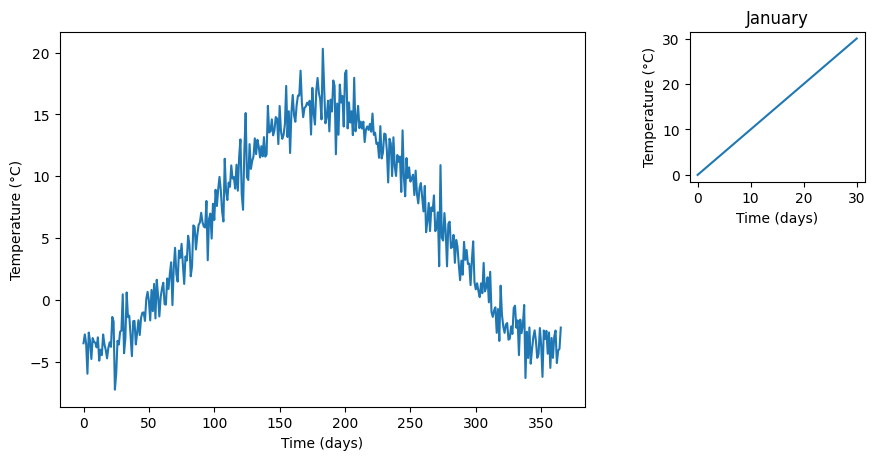

In [10]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_axes([0,0,0.75,0.75])
ax2 = fig.add_axes([0.90,0.45,0.25,0.30])
#fig.add_axes([a,b,c,d)
#a is left: Distance from the left edge
#b is bottom: Distance from the bottom edge
#c is width: Fraction of figure width occupied
#d is height: Fraction of figure height occupied
# So (0, 0) is the bottom-left corner and (1, 1) is the top-right corner.
ax1.plot(valley_celsius)
ax1.set_xlabel("Time (days)")
ax1.set_ylabel("Temperature (°C)")
ax2.plot(days[:31])
ax2.set_xlabel("Time (days)")
ax2.set_ylabel("Temperature (°C)")
ax2.set_title("January")
plt.show()

## Exercise 2: A grid of panels

With `plt.subplots(2, 2, figsize=(9, 5))`, give each of the three station records and the
humidity series its own panel. Print the shape of the axes array, label every panel with its
quantity and unit, give each a title, and pack the figure with `tight_layout`.

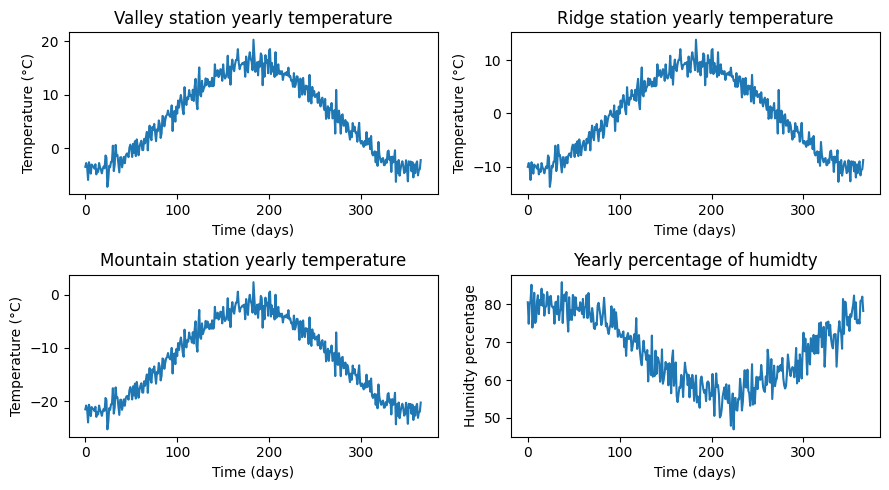

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(9, 5))
# ax0, ax1, ax2, ax3 = axes, would not work because, When you use plt.subplots(2, 2), axes is a 2 × 2 array, not a flat list of four axes. You're trying to unpack two rows into four variables.
ax0, ax1 = axes[0]
ax2, ax3 = axes[1]
ax0.plot(valley_celsius)
ax0.set_xlabel("Time (days)")
ax0.set_ylabel("Temperature (°C)")
ax0.set_title("Valley station yearly temperature")
ax1.plot(ridge_celsius)
ax1.set_xlabel("Time (days)")
ax1.set_ylabel("Temperature (°C)")
ax1.set_title("Ridge station yearly temperature")
ax2.plot(mountain_celsius)
ax2.set_xlabel("Time (days)")
ax2.set_ylabel("Temperature (°C)")
ax2.set_title("Mountain station yearly temperature")
ax3.plot(rh_percent)
ax3.set_xlabel("Time (days)")
ax3.set_ylabel("Humidty percentage")
ax3.set_title("Yearly percentage of humidty")
plt.tight_layout()
plt.show()

## Exercise 3: Telling series apart without colour

Plot all three station records on one axes so that they stay distinguishable printed in black
and white: all three in black, one solid, one dashed, one dotted. Then add every thirtieth point
of the valley record as circular markers with no line joining them. Add a legend.

In a second figure, draw the valley record as it would read at twelve elevations, from 0 m to
2200 m every 200 m, cooling by 6.5 °C per 1000 m, and name each curve in a legend. The default
colour cycle has ten entries, so two of the twelve curves repeat earlier colours. Say in a comment
which ones, and make them distinguishable by drawing every curve after the tenth dashed.

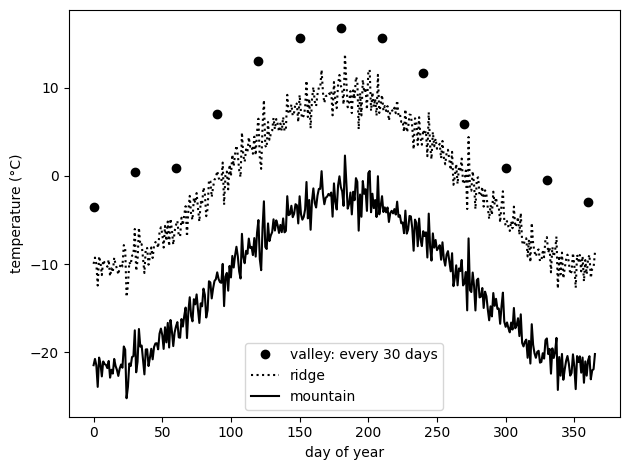

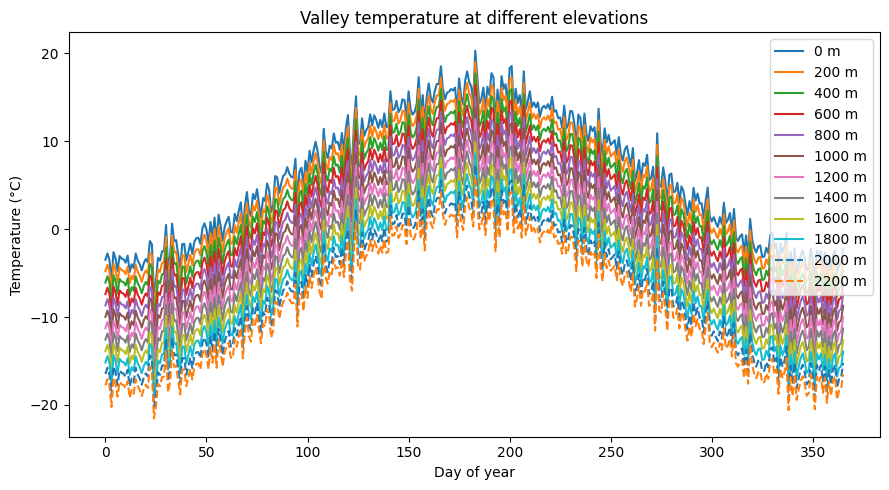

In [12]:
fig, ax = plt.subplots()
ax.plot(days[::30],valley_celsius[::30], color="k", linestyle="none",marker="o",label="valley: every 30 days")
ax.plot(days, ridge_celsius, color="k", linestyle="dotted", label = "ridge")
ax.plot(days, mountain_celsius, color="k", label="mountain")
ax.set_xlabel("day of year")
ax.set_ylabel("temperature (°C)")
ax.legend()
plt.tight_layout()
plt.show()

# Create the elevations: 0 m, 200 m, ..., 2200 m
elevations = np.arange(0, 2201, 200)
fig2, ax = plt.subplots(figsize=(9, 5))
# Plot the temperature record at each elevation
for i, elevation in enumerate(elevations):
   temperature = valley_celsius - 6.5 * elevation / 1000
    # Calculate the temperature decrease with elevation
   if i >= 10:
        ax.plot(days, temperature, linestyle="dashed",
                label=f"{elevation} m")
   else:
        ax.plot(days, temperature, label=f"{elevation} m")
    # The default colour cycle has 10 colours.
    # Elevations 2000 m and 2200 m repeat the colours of 0 m and 200 m.
    # Make every curve after the tenth dashed to distinguish them.
ax.set_xlabel("Day of year")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Valley temperature at different elevations")
ax.legend()

plt.tight_layout()
plt.show()

## Exercise 4: Ticks, gridlines, and axis limits

Plot the valley record with a tick at the first day of every month, labelled with the month's
initial (`"J"`, `"F"`, `"M"`, ...). The month lengths of 2024 are below; each month starts on the
running total of the lengths of the months before it, and an array's `.cumsum()` gives running
totals (1.3). Add major y ticks every 5 °C and minor ones every 1 °C, with a solid major grid and
a dotted minor grid.

In a second figure, show July and August only, taking the x-limits from the start days you
computed, and set the y-limits to leave 1 °C of space above and below the data in those two
months.

```python
month_days = np.array([31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])   # 2024
```

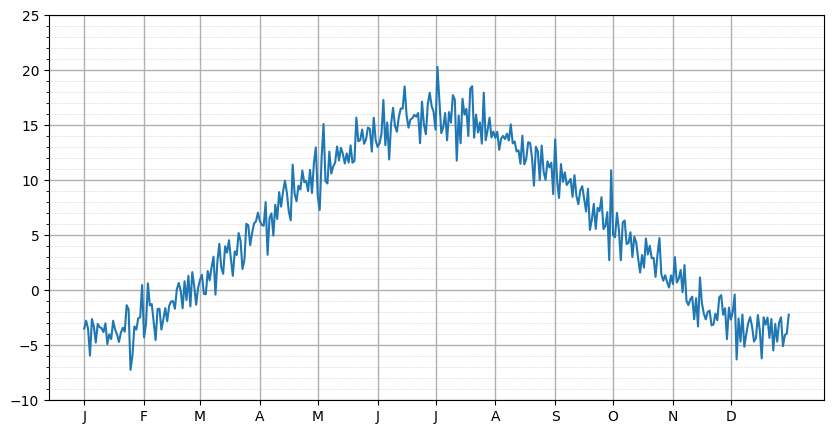

In [13]:
month_days = np.array([31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])   # 2024
# Calculate the starting day of each month
month_starts = np.insert(month_days[:-1].cumsum(), 0, 0)
# Month initials
month_labels = (["J", "F", "M", "A", "M", "J","J", "A", "S", "O", "N", "D"])
fig, ax = plt.subplots(figsize=(10, 5))
# Plot the valley temperature record
ax.plot(days, valley_celsius)
# Put a tick at the first day of every month
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.set_yticks(np.arange(-10, 21, 5))                # major ticks: every 5 °C
ax.set_yticks(np.arange(-10, 21, 1), minor=True)    # minor ticks: every 1 °C
ax.grid(which="major", linestyle="solid", linewidth=1)
ax.grid(which="minor", linestyle="--", linewidth=0.4)
# Find the minimum and maximum temperatures
y_min = np.floor(valley_celsius.min() / 5) * 5
y_max = np.ceil(valley_celsius.max() / 5) * 5

# Set major ticks every 5 °C
ax.set_yticks(np.arange(y_min, y_max + 1, 5))

# Set minor ticks every 1 °C
ax.set_yticks(np.arange(y_min, y_max + 1, 1), minor=True)

# Add grids
ax.grid(which="major", linestyle="-")
ax.grid(which="minor", linestyle=":")
plt.show()

## Exercise 5: Annotate the largest jump

Find the largest one-day warming in the valley record: the day on which the temperature rose most
from the day before. The change from each day to the next is one slice of the record minus
another, offset by one day, and `np.argmax` of that change locates the jump. Print the day of year
of the warmer day and the size of the jump, mark the warmer day on the plot with `ax.annotate` and
an arrow, and add a plain `ax.text` label in an empty part of the figure.

Day of year: 273
Largest one-day warming: 8.164840388234929 °C


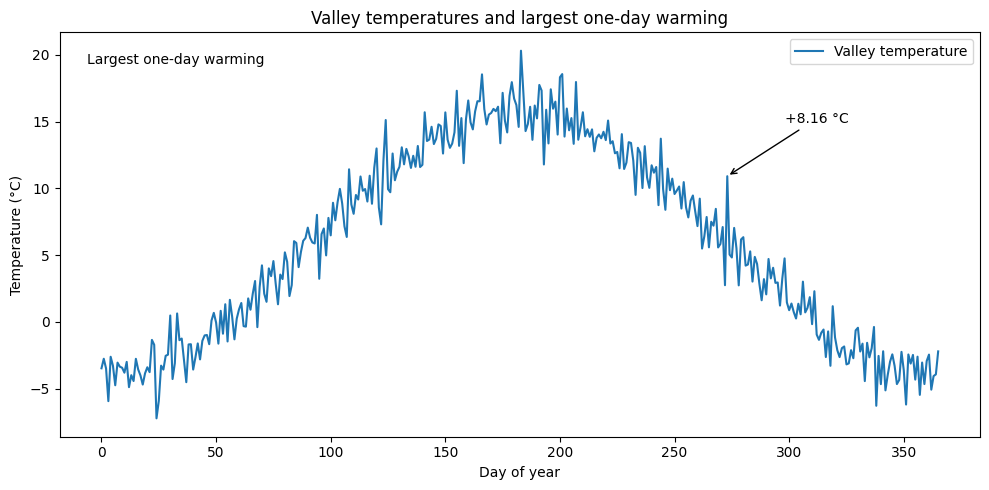

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate the temperature change from each day to the next
change = valley_celsius[1:] - valley_celsius[:-1]

# Find the index of the largest temperature increase
i = np.argmax(change)

# Find the warmer day and the size of the temperature increase
warmer_day = days[i + 1]
largest_warming = change[i]

# Print the results
print("Day of year:", warmer_day)
print("Largest one-day warming:", largest_warming, "°C")

# Plot the valley temperature record
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(days, valley_celsius, label="Valley temperature")

# Mark the warmer day with an annotation and arrow
ax.annotate(
    f"+{largest_warming:.2f} °C",
    xy=(warmer_day, valley_celsius[i + 1]),
    xytext=(warmer_day + 25, valley_celsius[i + 1] + 4),
    arrowprops=dict(arrowstyle="->")
)

# Add a plain text label in an empty part of the figure
ax.text(0.03, 0.95, "Largest one-day warming",
        transform=ax.transAxes, va="top")

# Add labels and legend
ax.set_xlabel("Day of year")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Valley temperatures and largest one-day warming")
ax.legend()

plt.tight_layout()
plt.show()

## Exercise 6: Two y-axes

Saturation vapour pressure, the pressure of water vapour in equilibrium with a flat water surface,
rises steeply with temperature. The Magnus approximation below gives it, in hPa, from the valley
record. Draw the valley temperature
and the saturation vapour pressure on one time axis with `twinx`, temperature against the left
y-axis and vapour pressure against the right, each line and its axis in a matching colour.

Then misuse the same tool: draw the valley and mountain records with `twinx`, valley on the left and
mountain on the right, and let matplotlib choose both ranges. In a third figure, draw the two records
on a single axes. In a comment, say what the twin-axis figure suggests about the two stations that
the single axes shows to be false, and when a second y-axis is the wrong choice.

```python
e_sat_hpa = 6.112 * np.exp(17.62 * valley_celsius / (243.12 + valley_celsius))   # Magnus, over water
```

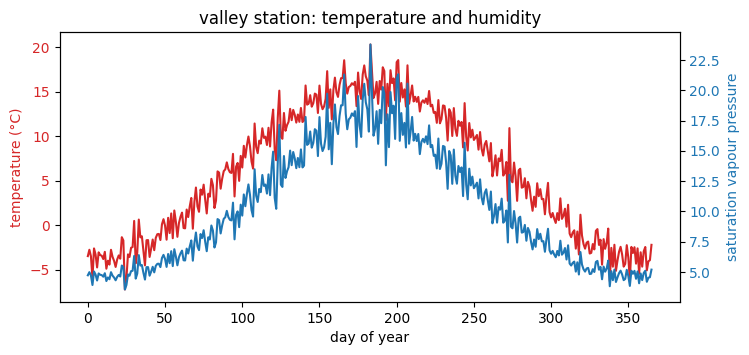

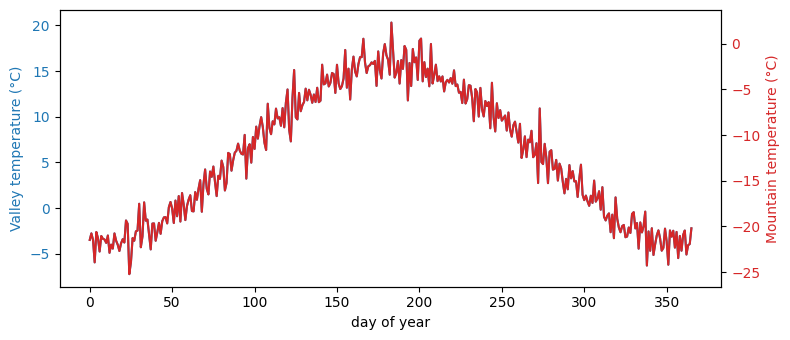

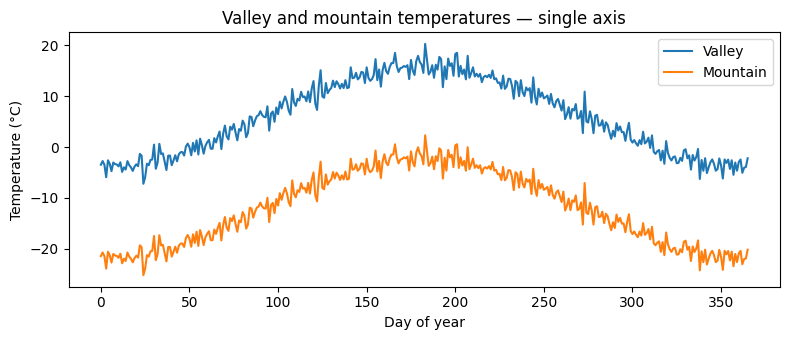

In [15]:
e_sat_hpa = 6.112 * np.exp(17.62 * valley_celsius / (243.12 + valley_celsius))
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(days, valley_celsius, color="tab:red")
ax.set_xlabel("day of year")
ax.set_ylabel("temperature (°C)", color="tab:red")
ax.tick_params(axis="y", labelcolor="tab:red")

ax_rh = ax.twinx()                     # same x-axis, a new y-axis on the right
ax_rh.plot(days, e_sat_hpa, color="tab:blue")
ax_rh.set_ylabel("saturation vapour pressure", color="tab:blue")
ax_rh.tick_params(axis="y", labelcolor="tab:blue")

ax.set_title("valley station: temperature and humidity")
plt.show()

#misuse:
fig, ax1 = plt.subplots(figsize=(8, 3.5))
ax1.plot(days, valley_celsius, color="tab:blue")
ax1.set_xlabel("day of year")
ax1.set_ylabel("Valley temperature (°C)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()                     # same x-axis, a new y-axis on the right
ax2.plot(days,mountain_celsius, color="tab:red")
ax2.set_ylabel("Mountain temperature (°C)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax.set_title("valley station & mountain station")
plt.tight_layout()
plt.show()
#The problem is that twinx() creates two independent y-axes, and Matplotlib automatically chooses a separate temperature range for each one.
#The left axis shows valley temperatures.
#The right axis shows mountain temperatures.
#Because each axis has its own scale, the two curves can appear to overlap or have similar ranges, even though the mountain is always 18°C colder.

# Create the third figure
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.plot(days, valley_celsius, label="Valley")
ax.plot(days, mountain_celsius, label="Mountain")

ax.set_xlabel("Day of year")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Valley and mountain temperatures — single axis")
ax.legend()

plt.tight_layout()
plt.show()

# The twin-axis plot can make the valley and mountain records appear
# to have similar temperature ranges or to overlap closely.
# The single-axis plot reveals that the mountain is consistently
# 18 °C colder than the valley.
# A second y-axis is misleading when it makes quantities directly
# comparable in the same units appear more similar than they are.

## Exercise 7: A parametric plot

The setup cell's humidity series lags temperature by about 30 days. Build a second one that lags
by 90 days (below), average the valley record and both humidity series into twelve monthly means
with `[:360].reshape(12, 30).mean(axis=1)`, and draw both loops on one axes: humidity against
temperature, a marker at each month, and a legend saying which lag is which. In a comment, say how
the loop changes as the lag grows, and what the twelve points would look like with no lag at all.

```python
rh_lag90_percent = 68.0 + 12.0 * np.cos(2 * np.pi * (days - 90) / 366) + rng.normal(0, 3.0, size=366)
```

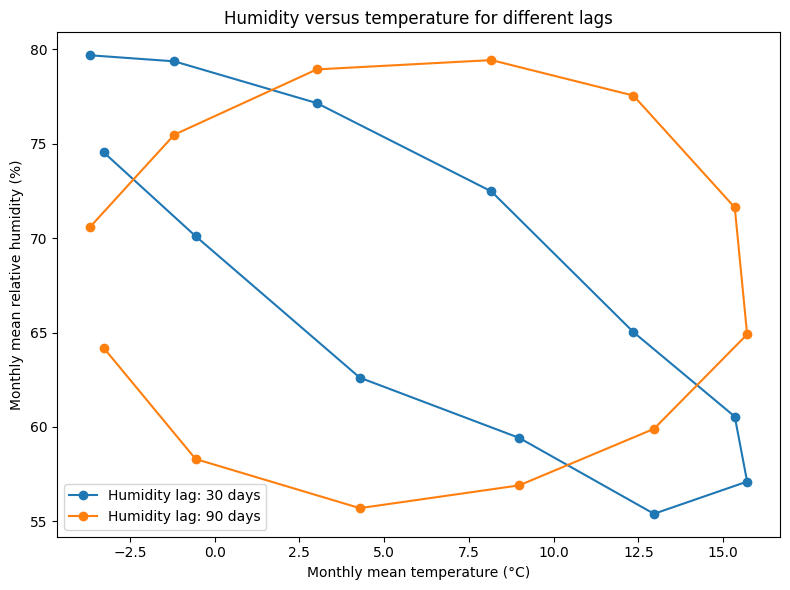

In [16]:
rh_lag90_percent = 68.0 + 12.0 * np.cos(2 * np.pi * (days - 90) / 366) + rng.normal(0, 3.0, size=366)
monthly_temperature = valley_celsius[:360].reshape(12, 30).mean(axis=1)
# Calculate the monthly mean humidity with a 30-day lag
monthly_rh_lag30 = rh_percent[:360].reshape(12, 30).mean(axis=1)

# Calculate the monthly mean humidity with a 90-day lag
monthly_rh_lag90 = rh_lag90_percent[:360].reshape(12, 30).mean(axis=1)

# Plot both humidity-temperature relationships on the same axes
fig, ax = plt.subplots(figsize=(8, 6))

# Plot humidity with a 30-day lag
ax.plot(
    monthly_temperature,
    monthly_rh_lag30,
    marker="o",
    label="Humidity lag: 30 days"
)

# Plot humidity with a 90-day lag
ax.plot(
    monthly_temperature,
    monthly_rh_lag90,
    marker="o",
    label="Humidity lag: 90 days"
)

# Add axis labels, a title, and a legend
ax.set_xlabel("Monthly mean temperature (°C)")
ax.set_ylabel("Monthly mean relative humidity (%)")
ax.set_title("Humidity versus temperature for different lags")
ax.legend()

plt.tight_layout()
plt.show()

# As the lag increases, the loop changes because humidity peaks later
# relative to temperature, changing the shape and direction of the loop.
# With no lag, the twelve points would tend to follow a single curve
# rather than form a loop, because humidity and temperature would peak
# at approximately the same time.

## Exercise 8: Comparing two distributions

Draw the distributions of daily temperature at the valley and mountain stations as two histograms
on one axes. Give them the same bin edges — `bins` also accepts an array of edges, which
`np.linspace` can build to span both records — and draw them semi-transparent with `alpha=0.6`, so
the overlap stays visible. Add a legend and label both axes. In a comment, say how the two
distributions differ, and why.

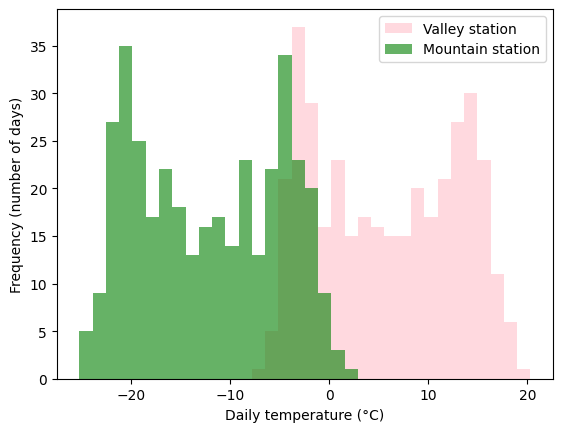

In [30]:
min_temp = min(valley_celsius.min(), mountain_celsius.min())
max_temp = max(valley_celsius.max(), mountain_celsius.max())

# Create shared bin edges spanning both temperature records
bins = np.linspace(min_temp, max_temp, 35)

# Create a figure and plot both histograms on the same axes
plt.figure()
plt.hist(valley_celsius, bins=bins, alpha=0.6, label='Valley station',color="pink")
plt.hist(mountain_celsius, bins=bins, alpha=0.6, label='Mountain station',color="green")

# Add axis labels, a legend, and display the figure
plt.xlabel('Daily temperature (°C)')
plt.ylabel('Frequency (number of days)')
plt.legend()
plt.show()

# The valley station generally has higher temperatures, while the mountain station
# has lower temperatures because temperature decreases with altitude.

## Exercise 9: Monthly means as bars

Average the valley record into twelve monthly means with `[:360].reshape(12, 30).mean(axis=1)`
and draw them as a bar chart, one bar per month, with the month's initial as each tick label.
Colour the freezing months (mean below 0 °C) with the hex code `"#2c7bb6"` and the others with the
grey level `"0.6"` — `color` also accepts a list with one colour per bar. On a second axes beside
it, compare the annual means of the three stations with `barh`. Label the value axis with its unit
in both.

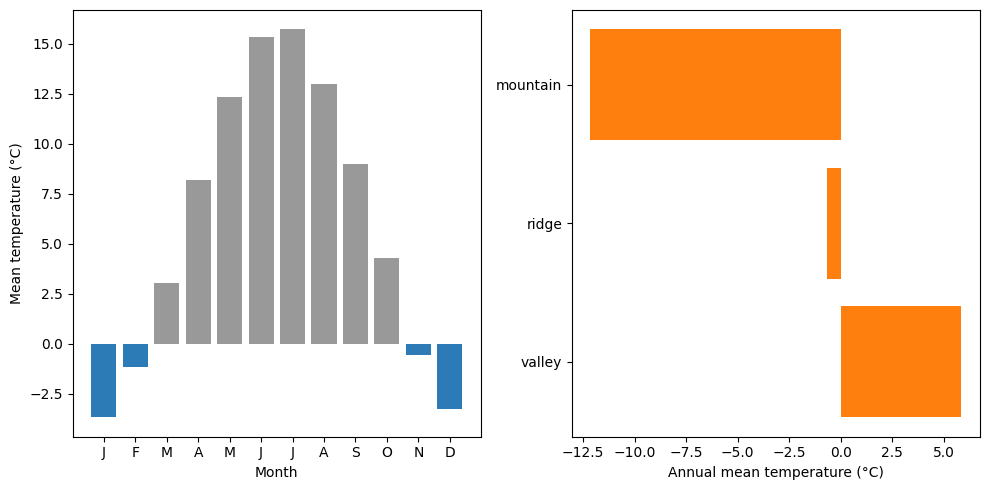

In [45]:
monthly_means = valley_celsius[:360].reshape(12, 30).mean(axis=1)
# Define the number of days in each calendar month
month_days = np.array([31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
# Calculate the starting day of each month
month_starts = np.insert(month_days[:-1].cumsum(), 0, 0)
# Define the month labels
month_labels = ["J", "F", "M", "A", "M", "J",
                "J", "A", "S", "O", "N", "D"]
# Choose blue for freezing months and grey for the others
colors = ["#2c7bb6" if temp < 0 else "0.6" for temp in monthly_means]
# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 5),ncols=2)
# Plot the twelve monthly mean temperatures
ax[0].bar(np.arange(12), monthly_means, color=colors)
# Label the months on the x-axis
ax[0].set_xticks(np.arange(12))
ax[0].set_xticklabels(month_labels)
# Label the axes
ax[0].set_xlabel("Month")
ax[0].set_ylabel("Mean temperature (°C)")
# Calculate the annual mean temperatures of the three stations
stations = ["valley", "ridge", "mountain"]
annual_mean_celsius = [valley_celsius.mean(), ridge_celsius.mean(), mountain_celsius.mean()]
# Compare the annual means using horizontal bars
ax[1].barh(stations, annual_mean_celsius, color="tab:orange")
ax[1].set_xlabel("Annual mean temperature (°C)")

plt.tight_layout()
plt.show()

## Exercise 10: One field, four ways

Build the small gridded field below, then draw it four times in a 2 × 2 figure: with `imshow`
(row 0 is the southernmost latitude, so make it appear at the bottom), with `pcolormesh` using
the coordinates as cell centres, with `contourf` using 8 levels, and with `pcolormesh` and
`shading="flat"`. The last needs the cell *edges*: one more value than there are centres along
each axis, starting half a grid step before the first centre. It should come out identical to the
second panel. Label the `imshow` panel's axes in grid index and the other three in degrees, give
each panel a labelled colorbar, and save the figure as `_files/field.svg`.

```python
lon = np.linspace(6.0, 9.0, 6)
lat = np.linspace(46.0, 47.5, 4)      # ascending: south -> north
field_celsius = 6.0 + (46.0 - lat)[:, None] * 3.0 + rng.normal(0, 1.0, size=(4, 6))
```

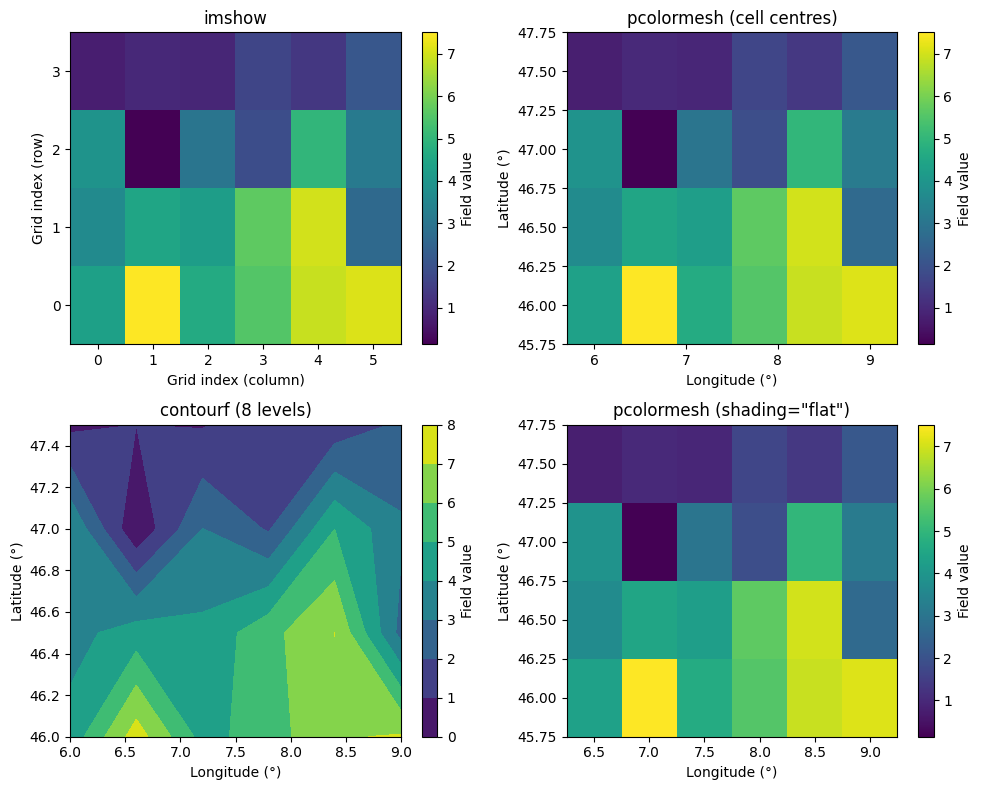

In [49]:
from pathlib import Path
lon = np.linspace(6.0, 9.0, 6)
lat = np.linspace(46.0, 47.5, 4)      # ascending: south -> north
field_celsius = 6.0 + (46.0 - lat)[:, None] * 3.0 + rng.normal(0, 1.0, size=(4, 6))
# Calculate the grid spacing
lon_edges = np.arange(6.25, 9.30, 0.5)
lat_edges = np.arange(45.75, 47.80, 0.5)

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# Panel 1: imshow, with row 0 at the bottom
im0 = ax[0, 0].imshow(field_celsius, origin="lower", aspect="auto")
ax[0, 0].set_title("imshow")
ax[0, 0].set_xlabel("Grid index (column)")
ax[0, 0].set_ylabel("Grid index (row)")
ax[0, 0].set_xticks(np.arange(len(lon)))
ax[0, 0].set_yticks(np.arange(len(lat)))
fig.colorbar(im0, ax=ax[0, 0], label="Field value")

# Panel 2: pcolormesh, using coordinates as cell centres
im1 = ax[0, 1].pcolormesh(lon, lat, field_celsius, shading="nearest")
ax[0, 1].set_title("pcolormesh (cell centres)")
ax[0, 1].set_xlabel("Longitude (°)")
ax[0, 1].set_ylabel("Latitude (°)")
fig.colorbar(im1, ax=ax[0, 1], label="Field value")

# Panel 3: contourf, using 8 contour levels
im2 = ax[1, 0].contourf(lon, lat, field_celsius, levels=8)
ax[1, 0].set_title("contourf (8 levels)")
ax[1, 0].set_xlabel("Longitude (°)")
ax[1, 0].set_ylabel("Latitude (°)")
fig.colorbar(im2, ax=ax[1, 0], label="Field value")

# Panel 4: pcolormesh, using cell edges and flat shading
im3 = ax[1, 1].pcolormesh(
    lon_edges, lat_edges, field_celsius, shading="flat"
)
ax[1, 1].set_title('pcolormesh (shading="flat")')
ax[1, 1].set_xlabel("Longitude (°)")
ax[1, 1].set_ylabel("Latitude (°)")
fig.colorbar(im3, ax=ax[1, 1], label="Field value")

# Adjust spacing and save the figure
plt.tight_layout()
Path("_files").mkdir(parents=True, exist_ok=True)
plt.savefig("_files/field.svg", format="svg", bbox_inches="tight")
plt.show()

#imshow(): Displays the array as an image, with each value represented by a coloured pixel. Axes show grid indices by default. origin="lower" places the southernmost row at the bottom. Best for quickly visualising a 2D array.
#pcolormesh() with shading="nearest": Uses longitude and latitude coordinates as cell centres and colours the surrounding area according to each value. Best for displaying geographically referenced grid data when cell centres are known.
#contourf(): Groups values into coloured intervals and fills regions between contour levels. Best for visualising spatial patterns, gradients, and areas with similar values.
#pcolormesh() with shading="flat": Colours each grid cell using its value and explicitly defined cell edges. Requires one more edge than centre along each axis. Best when the boundaries of the grid cells matter.

## Exercise 11: A vector field

Build the synthetic wind field below — a simple rotation, like a cyclone seen from above — and
draw it two ways in a 1 × 2 figure. On the left, `quiver` at every third grid point, over
`contour` lines of the wind speed. On the right, `streamplot` coloured by wind speed, with a
labelled colorbar whose unit, metres per second, is written with mathtext (1.4.5) so the
exponent is a real superscript. Label the axes in km.

```python
x_km = np.linspace(-100, 100, 25)
y_km = np.linspace(-100, 100, 25)
xx_km, yy_km = np.meshgrid(x_km, y_km)
u_ms = -yy_km / 8.0
v_ms = xx_km / 8.0
```

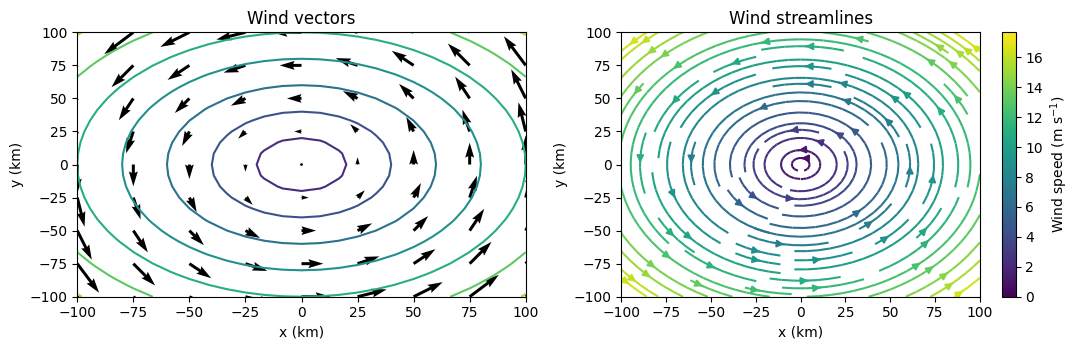

In [54]:
x_km = np.linspace(-100, 100, 25)
y_km = np.linspace(-100, 100, 25)
xx_km, yy_km = np.meshgrid(x_km, y_km)

# Build the synthetic rotating wind field
u_ms = -yy_km / 8.0
v_ms = xx_km / 8.0

# Calculate wind speed
speed_ms = np.sqrt(u_ms**2 + v_ms**2)

# Create two plots side by side
fig, axes = plt.subplots(figsize=(11, 3.6), ncols=2)

# Left: quiver arrows over wind-speed contour lines
axes[0].contour(xx_km, yy_km, speed_ms)
axes[0].quiver(
    xx_km[::3, ::3], yy_km[::3, ::3],
    u_ms[::3, ::3], v_ms[::3, ::3]
)
axes[0].set_xlabel("x (km)")
axes[0].set_ylabel("y (km)")
axes[0].set_title("Wind vectors")
# Right: streamlines coloured by wind speed
sp = axes[1].streamplot(
    xx_km, yy_km, u_ms, v_ms,
    density=1.0, color=speed_ms, cmap="viridis"
)
axes[1].set_xlabel("x (km)")
axes[1].set_ylabel("y (km)")
axes[1].set_title("Wind streamlines")

# Add a labelled colourbar with a superscript exponent
fig.colorbar(sp.lines, ax=axes[1], label=r"Wind speed (m s$^{-1}$)")

plt.tight_layout()
plt.show()

## Exercise 12: Fix the map

The cell below draws a temperature anomaly field — the departure from a long-term mean, in °C, on
a 0.5° grid over the Alps — and breaks most of the checklist in 1.4.12. First list every practice
it breaks, as comments. Then redraw the same data so that it passes all of them.

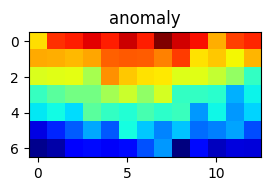

In [58]:
# Pre-supplied: a map that breaks most of the checklist.
# Leave this cell as it is -- write the corrected version in the next one.
anomaly_lon = np.linspace(5.0, 11.0, 13)
anomaly_lat = np.linspace(45.0, 48.0, 7)                     # ascending: south -> north
anomaly_celsius = ((46.5 - anomaly_lat)[:, None] * 1.5
                   + 0.4 * np.sin(anomaly_lon)[None, :]
                   + rng.normal(0, 0.3, size=(7, 13)))

fig, ax = plt.subplots(figsize=(3, 2))
ax.imshow(anomaly_celsius, cmap="jet")
ax.set_title("anomaly")
plt.show()
# 1. Does not use geographic coordinates for the axes.
# 2. Does not specify the extent to map pixels to longitude and latitude.
# 3. Does not set origin="lower", so the southernmost latitude may appear at the top.
# 4. Uses the "jet" colormap, which is not ideal for displaying temperature anomalies.
# 5. Does not label the x-axis with longitude and units.
# 6. Does not label the y-axis with latitude and units.
# 7. Does not include a colorbar to explain the temperature anomaly values.
# 8. Does not label the colorbar with the variable and its unit (°C).
# 9. Uses a figure that is too small for a clear geographic map.

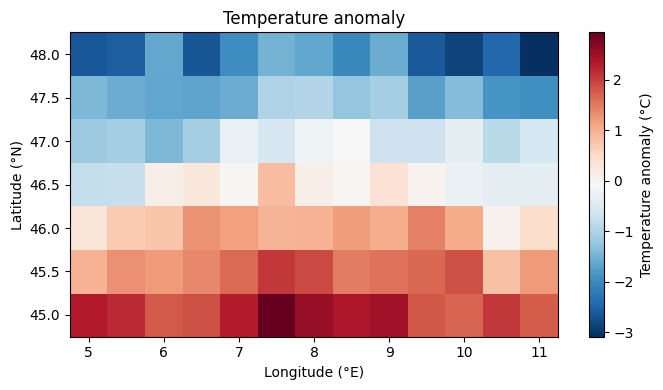

In [57]:
# Create the figure
fig, ax = plt.subplots(figsize=(7, 4))
anomaly_lon = np.linspace(5.0, 11.0, 13)
anomaly_lat = np.linspace(45.0, 48.0, 7)
anomaly_celsius = ((46.5 - anomaly_lat)[:, None] * 1.5
                   + 0.4 * np.sin(anomaly_lon)[None, :]
                   + rng.normal(0, 0.3, size=(7, 13)))
# Display the anomaly field using geographic coordinates
im = ax.imshow(
    anomaly_celsius,
    extent=[
        anomaly_lon[0] - (anomaly_lon[1] - anomaly_lon[0]) / 2,
        anomaly_lon[-1] + (anomaly_lon[1] - anomaly_lon[0]) / 2,
        anomaly_lat[0] - (anomaly_lat[1] - anomaly_lat[0]) / 2,
        anomaly_lat[-1] + (anomaly_lat[1] - anomaly_lat[0]) / 2
    ],
    origin="lower",
    aspect="auto",
    cmap="RdBu_r"
)

# Label the geographic axes
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Temperature anomaly")

# Add a labelled colourbar with units
fig.colorbar(im, ax=ax, label="Temperature anomaly (°C)")

plt.tight_layout()
plt.show()

## Exercise 13: Build a labelled DataArray

From `data = np.arange(12.0).reshape(3, 4)`, build an xarray DataArray with dimensions
`("lat", "lon")`, latitude coordinates `[46.0, 46.5, 47.0]`, longitude coordinates
`[6.0, 6.5, 7.0, 7.5]`, and a `units` attribute of `"degC"`. Print its dims and its units.

In [59]:
import numpy as np
import xarray as xr
# Create the data array
data = np.arange(12.0).reshape(3, 4)

# Build the xarray DataArray with dimensions and coordinates
temperature = xr.DataArray(
    data,
    dims=("lat", "lon"),
    coords={
        "lat": [46.0, 46.5, 47.0],
        "lon": [6.0, 6.5, 7.0, 7.5]
    },
    attrs={"units": "degC"}
)

# Print the dimensions and units
print(temperature.dims)
print(temperature.attrs["units"])

('lat', 'lon')
degC


## Exercise 14: Select, reduce, and subtract

Build the small Dataset below, then:

1. Print the spatial mean of the first day (by position) and the time mean at each longitude
   along 47.0° N (by label).
2. Select the grid point nearest 46.8° N, 6.3° E, and print its coordinates and its ten values.
3. Subtract each day's spatial mean — the mean over `lat` and `lon` — from the field. Print the
   dims of the result, and its spatial mean on the first day, which should be zero up to rounding.

```python
rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2024-01-11", dtype="datetime64[D]")
lat = np.array([46.0, 46.5, 47.0]); lon = np.array([6.0, 6.5, 7.0, 7.5])
t = rng.normal(5, 3, size=(10, 3, 4))
ds = xr.Dataset({"t2m": (("time", "lat", "lon"), t)},
                coords={"time": time, "lat": lat, "lon": lon})
```

In [60]:
import numpy as np
import xarray as xr

# Build the Dataset
rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2024-01-11", dtype="datetime64[D]")
lat = np.array([46.0, 46.5, 47.0])
lon = np.array([6.0, 6.5, 7.0, 7.5])
t = rng.normal(5, 3, size=(10, 3, 4))

ds = xr.Dataset(
    {"t2m": (("time", "lat", "lon"), t)},
    coords={"time": time, "lat": lat, "lon": lon}
)

# 1. Spatial mean of the first day (by position)
first_day_mean = ds["t2m"].isel(time=0).mean(dim=("lat", "lon"))
print("Spatial mean on the first day:")
print(first_day_mean.values)

# 2. Time mean at each longitude along 47.0° N (by label)
time_mean = ds["t2m"].sel(lat=47.0).mean(dim="time")
print("\nTime mean at 47.0° N for each longitude:")
print(time_mean)

# 3. Select the nearest grid point to 46.8° N, 6.3° E
nearest_point = ds["t2m"].sel(lat=46.8, lon=6.3, method="nearest")
print("\nNearest grid point coordinates:")
print("Latitude:", nearest_point.lat.values)
print("Longitude:", nearest_point.lon.values)

print("Ten temperature values:")
print(nearest_point.values)

# 4. Subtract each day's spatial mean from the field
daily_spatial_mean = ds["t2m"].mean(dim=("lat", "lon"))
anomaly = ds["t2m"] - daily_spatial_mean

# Print the dimensions of the result
print("\nDimensions of the anomaly field:")
print(anomaly.dims)

# Print the spatial mean on the first day (should be approximately zero)
print("\nSpatial mean of the anomaly field on the first day:")
print(anomaly.isel(time=0).mean(dim=("lat", "lon")).values)

Spatial mean on the first day:
5.066212406340753

Time mean at 47.0° N for each longitude:
<xarray.DataArray 't2m' (lon: 4)> Size: 32B
array([5.71578037, 4.06925602, 4.77650243, 6.33699185])
Coordinates:
  * lon      (lon) float64 32B 6.0 6.5 7.0 7.5
    lat      float64 8B 47.0

Nearest grid point coordinates:
Latitude: 47.0
Longitude: 6.5
Ten temperature values:
[ 1.20373559  9.09939041  6.62253675  4.05823156  7.08812817 -1.61052964
  3.10041773  2.79355012  1.15881817  7.17828137]

Dimensions of the anomaly field:
('time', 'lat', 'lon')

Spatial mean of the anomaly field on the first day:
-1.4802973661668753e-16


## Exercise 15: Monthly anomalies, two ways

Build the one-year daily temperature DataArray below and subtract its annual mean to get each
day's anomaly. Compute the monthly mean anomaly with `resample`, and print the calendar month
(1–12) whose mean anomaly is largest. Then compute the monthly mean anomaly again with
`groupby("time.month")`, and print the largest difference between the two sets of twelve values.
In a comment, say why the two agree here, and what would differ between them for a ten-year
record.

```python
rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2025-01-01", dtype="datetime64[D]")
n = time.size; doy = np.arange(n)
t = 5 + -np.cos(2 * np.pi * doy / n) * 10 + rng.normal(0, 1.5, n)
da = xr.DataArray(t, dims="time", coords={"time": time}, attrs={"units": "degC"})
```

In [61]:
# Build one year of daily temperatures
rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2025-01-01", dtype="datetime64[D]")
temperature = rng.normal(10, 5, size=len(time))

# Create the DataArray
t2m = xr.DataArray(
    temperature,
    dims=("time",),
    coords={"time": time},
    attrs={"units": "degC"}
)

# Calculate each day's anomaly relative to the annual mean
anomaly = t2m - t2m.mean()

# Calculate monthly mean anomalies using resample
monthly_resample = anomaly.resample(time="MS").mean()

# Print the calendar month with the largest mean anomaly
largest_month = int(monthly_resample.time[
    monthly_resample.argmax(dim="time")
].dt.month.values)

print("Month with largest mean anomaly:", largest_month)

# Calculate monthly mean anomalies using groupby
monthly_groupby = anomaly.groupby("time.month").mean()

# Calculate the largest absolute difference between the two methods
largest_difference = np.abs(
    monthly_resample.values - monthly_groupby.values
).max()

print("Largest difference:", largest_difference)

# The two methods agree here because there is one complete year of daily data:
# each calendar month appears only once, so resample and groupby calculate
# the same monthly means. For a ten-year record, resample gives a separate
# monthly mean for each month of each year (120 values), whereas groupby
# combines all Januaries, all Februaries, etc. into 12 long-term monthly means.

Month with largest mean anomaly: 2
Largest difference: 0.0


## Exercise 16: Round-trip through netCDF

Build a Dataset holding one 1D temperature variable, `t2m`, with a `units` attribute. Write it to
`_files/series.nc`, reopen it with `open_dataset`, and print the variable names and the recovered
units.

In [62]:
import numpy as np
import xarray as xr
from pathlib import Path

# Build a one-dimensional temperature series
time = np.arange("2024-01-01", "2024-01-11", dtype="datetime64[D]")
temperature = np.arange(10.0)

# Create a Dataset with one temperature variable and its units
ds = xr.Dataset(
    {"t2m": ("time", temperature, {"units": "degC"})},
    coords={"time": time}
)

# Create the output directory if it does not exist
Path("_files").mkdir(parents=True, exist_ok=True)

# Save the Dataset to a netCDF file
ds.to_netcdf("_files/series.nc")

# Reopen the saved file
ds_reopened = xr.open_dataset("_files/series.nc")

# Print the variable names and recovered units
print("Variable names:", list(ds_reopened.data_vars))
print("Recovered units:", ds_reopened["t2m"].attrs["units"])

# Close the file
ds_reopened.close()

Variable names: ['t2m']
Recovered units: degC


## Exercise 17: What transform does

Rebuild the DataArray `da` from exercise 13 and draw it twice, side by side, on
`ccrs.EqualEarth()` maps cropped with `set_extent([5, 9, 45, 48], crs=ccrs.PlateCarree())` and
with `cfeature.BORDERS` added: once with `pcolormesh(..., transform=ccrs.PlateCarree())`, and
once with `transform` left out. Give the first panel a labelled colorbar. In a comment, say where
the field in the second panel went, and why no error was raised.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 58.6 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


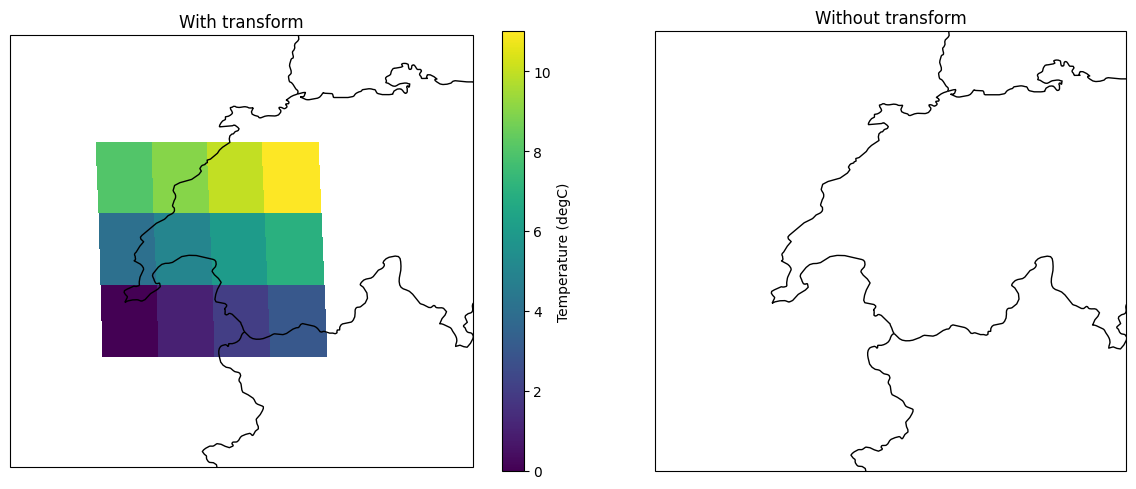

In [64]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
!pip install cartopy
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Rebuild the DataArray da from exercise 13
data = np.arange(12.0).reshape(3, 4)

da = xr.DataArray(
    data,
    dims=("lat", "lon"),
    coords={
        "lat": [46.0, 46.5, 47.0],
        "lon": [6.0, 6.5, 7.0, 7.5]
    },
    attrs={"units": "degC"}
)

# Create two Equal Earth map projections
fig, axes = plt.subplots(
    1, 2, figsize=(12, 5),
    subplot_kw={"projection": ccrs.EqualEarth()}
)

# First panel: correctly specify the data's coordinate system
im = axes[0].pcolormesh(
    da.lon, da.lat, da,
    transform=ccrs.PlateCarree()
)
axes[0].set_extent([5, 9, 45, 48], crs=ccrs.PlateCarree())
axes[0].add_feature(cfeature.BORDERS)
axes[0].set_title("With transform")

# Add a labelled colorbar to the first panel
fig.colorbar(im, ax=axes[0], label=f"Temperature ({da.attrs['units']})")

# Second panel: leave out the transform
axes[1].pcolormesh(da.lon, da.lat, da)
axes[1].set_extent([5, 9, 45, 48], crs=ccrs.PlateCarree())
axes[1].add_feature(cfeature.BORDERS)
axes[1].set_title("Without transform")

# The field in the second panel is misplaced because Cartopy assumes
# the coordinates are already in the map projection (Equal Earth),
# rather than longitude and latitude (Plate Carrée). No error is raised
# because the coordinates are valid numbers, even though they are
# interpreted in the wrong coordinate system.

plt.tight_layout()
plt.show()

## Exercise 18: Choosing a projection

Each figure described below needs a map. For each, choose a projection from 1.4.13 and draw the
empty map — land, ocean, and coastline, cropped with `set_extent` where the figure covers less
than the globe. Draw the three as panels of one figure; each panel needs its own projection, so
create each axes with `fig.add_subplot`. Justify each choice in a comment of one or two sentences.

1. The extent of Arctic sea ice in September. `ccrs.NorthPolarStereo()` is the northern
   counterpart of `SouthPolarStereo`.
2. How much of each continent is covered by tropical forest, for a reader who will compare the
   areas by eye.
3. A warm anomaly spreading through the Southern Ocean into the Atlantic, Indian, and Pacific
   basins, for a figure whose point is that the Southern Ocean links all three.

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://na

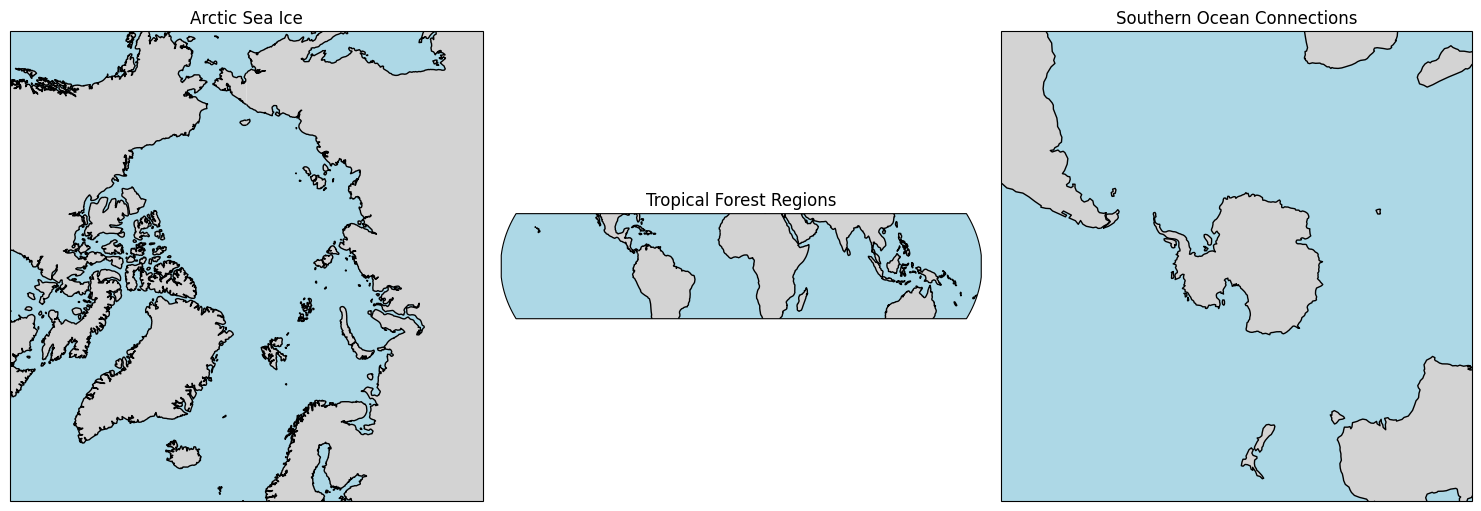

In [65]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create one figure to hold the three maps
fig = plt.figure(figsize=(15, 5))

# 1. Arctic sea ice in September
# North Polar Stereographic is suited to Arctic-focused maps because
# it represents the region around the North Pole clearly.
ax1 = fig.add_subplot(1, 3, 1, projection=ccrs.NorthPolarStereo())
ax1.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, facecolor="lightgray")
ax1.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax1.add_feature(cfeature.COASTLINE)
ax1.set_title("Arctic Sea Ice")

# 2. Tropical forest coverage by continent
# Equal Earth is an equal-area projection, so continent areas can be
# compared fairly by eye without projection distortion changing their relative areas.
ax2 = fig.add_subplot(1, 3, 2, projection=ccrs.EqualEarth())
ax2.set_extent([-180, 180, -30, 30], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.LAND, facecolor="lightgray")
ax2.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax2.add_feature(cfeature.COASTLINE)
ax2.set_title("Tropical Forest Regions")

# 3. Warm anomaly spreading through the Southern Ocean
# South Polar Stereographic focuses on the Southern Ocean and Antarctica,
# making the connected ocean around Antarctica the central feature of the map.
ax3 = fig.add_subplot(1, 3, 3, projection=ccrs.SouthPolarStereo())
ax3.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())
ax3.add_feature(cfeature.LAND, facecolor="lightgray")
ax3.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax3.add_feature(cfeature.COASTLINE)
ax3.set_title("Southern Ocean Connections")

plt.tight_layout()
plt.show()